## Exploratory Data Analysis

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.stats import ks_2samp

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.metrics import roc_auc_score

from evaluation import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data

In [45]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

In [46]:
y_train.value_counts()

y
0    2512
1    2488
Name: count, dtype: int64

In [66]:
scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [ ]:
# Mutual Information
mi_scores = mutual_info_classif(x_train_scaled, y_train, random_state=42)
mi_scores = pd.Series(mi_scores, index=x_train_scaled.columns)
mi_rank = mi_scores.rank(ascending=False, method="min")


# ANOVA F-score
f_scores, p_values = f_classif(x_train_scaled, y_train)
f_scores = pd.Series(f_scores, index=x_train_scaled.columns)
f_rank = f_scores.rank(ascending=False, method="min")

# NOTE: corr - same ranking as F-score
# Pearson Correlation
# corr_scores = pd.Series([np.abs(np.corrcoef(x_train_scaled[col], y_train)[0, 1]) for col in x_train_scaled.columns],
#                         index=x_train_scaled.columns)

# corr_scores = corr_scores.fillna(0)
# corr_rank = corr_scores.rank(ascending=False, method="min")


# AUC-ROC Scores
auc_scores = {}

for col in x_train_scaled.columns:
    auc = roc_auc_score(y_train, x_train_scaled[col])
    auc = max(auc, 1 - auc)
    auc_scores[col] = auc

auc_scores = pd.Series(auc_scores)
auc_rank = auc_scores.rank(ascending=False, method="min")


# KOLMOGOROV-SMIRNOV (KS) TEST
ks_scores = {}

for col in x_train_scaled.columns:

    class_0 = x_train_scaled.loc[y_train == 0, col]
    class_1 = x_train_scaled.loc[y_train == 1, col]

    stat, p_value = ks_2samp(class_0, class_1)
    ks_scores[col] = stat

ks_scores = pd.Series(ks_scores)
ks_rank = ks_scores.rank(ascending=False, method="min")


# Logistic Regression L1
l1 = LogisticRegression(penalty="l1", solver="saga", max_iter=5000)

l1.fit(x_train_scaled, y_train)
l1_scores = np.abs(l1.coef_[0])
l1_scores = pd.Series(l1_scores, index=x_train.columns)
l1_rank = l1_scores.rank(ascending=False)


# Tree-based importance
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

rf.fit(x_train_scaled, y_train)
rf_scores = pd.Series(rf.feature_importances_, index=x_train.columns)
rf_rank = rf_scores.rank(ascending=False)


# ===================
# RESULTS TABLE =====
# ===================

results = pd.DataFrame({
    "feature": x_train_scaled.columns,

    "mutual_info": mi_scores,
    "f_score": f_scores,
    "auc_roc": auc_scores,
    "ks_stat": ks_scores,
    "l1": l1_scores,
    "rf": rf_scores,

    "mi_rank": mi_rank,
    "f_rank": f_rank,
    "auc_roc_rank": auc_rank,
    "ks_stat_rank": ks_rank,
    "l1_rank": l1_rank,
    "rf_rank": rf_rank,

}).reset_index(drop=True)


rank_columns = [
    "mi_rank",
    "f_rank",
    "auc_roc_rank",
    "ks_stat_rank",
    "l1_rank",
    "rf_rank",
]

metric_columns = [
    "mutual_info",
    "f_score",
    "auc_roc",
    "ks_stat",
    "l1",
    "rf",
]

n_features = len(results)

for col in rank_columns:
    results[col + "_norm"] = (results[col] - 1) / (n_features - 1)


norm_rank_cols = [c + "_norm" for c in rank_columns]

results["avg_normalized_rank"] = (results[norm_rank_cols].mean(axis=1))

# lower = better
results = results.sort_values(by="avg_normalized_rank")

TOP_K = 200
results["votes_top_k"] = 0

for col in rank_columns:
    top_features = results.nsmallest(TOP_K, col)["feature"]
    results.loc[results["feature"].isin(top_features), "votes_top_k"] += 1

display(results)

,feature,mutual_info,f_score,auc_roc,ks_stat,l1,rf,mi_rank,f_rank,auc_roc_rank,ks_stat_rank,l1_rank,rf_rank,mi_rank_norm,f_rank_norm,auc_roc_rank_norm,ks_stat_rank_norm,l1_rank_norm,rf_rank_norm,avg_normalized_rank,votes_top_k
389,V390,0.008511,65.771559,0.555207,0.081085,3.602974,0.005130,76.0,1.0,7.0,16.0,1.0,12.0,0.150301,0.000000,0.012024,0.030060,0.000000,0.022044,0.035738,6
308,V309,0.009498,43.722840,0.553451,0.091623,0.837978,0.002826,64.0,10.0,9.0,9.0,7.0,24.0,0.126253,0.018036,0.016032,0.016032,0.012024,0.046092,0.039078,6
344,V345,0.009262,44.907550,0.547913,0.085407,2.104822,0.003451,68.0,8.0,13.0,13.0,3.0,22.0,0.134269,0.014028,0.024048,0.024048,0.004008,0.042084,0.040414,6
198,V199,0.008195,50.191733,0.551746,0.083627,2.346157,0.004915,79.0,7.0,11.0,14.0,2.0,15.0,0.156313,0.012024,0.020040,0.026052,0.002004,0.028056,0.040748,6
31,V32,0.006444,53.937593,0.558361,0.087775,1.197673,0.004429,108.0,4.0,3.0,10.0,4.5,18.0,0.214429,0.006012,0.004008,0.018036,0.007014,0.034068,0.047261,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,V297,0.002855,0.013476,0.500875,0.013545,0.009376,0.001525,178.0,463.0,463.0,489.0,408.0,486.0,0.354709,0.925852,0.925852,0.977956,0.815631,0.971944,0.828657,1
391,V392,0.000000,0.004008,0.500521,0.017319,0.009187,0.001619,257.0,483.0,481.0,444.0,409.0,451.0,0.513026,0.965932,0.961924,0.887776,0.817635,0.901804,0.841349,0
232,V233,0.000000,0.004007,0.500653,0.017388,0.009999,0.001520,257.0,484.0,474.0,443.0,404.0,487.0,0.513026,0.967936,0.947896,0.885772,0.807615,0.973948,0.849365,0
407,V408,0.000000,0.030760,0.500186,0.014426,0.000000,0.001603,257.0,443.0,494.0,480.0,465.5,460.0,0.513026,0.885772,0.987976,0.959920,0.930862,0.919840,0.866232,0


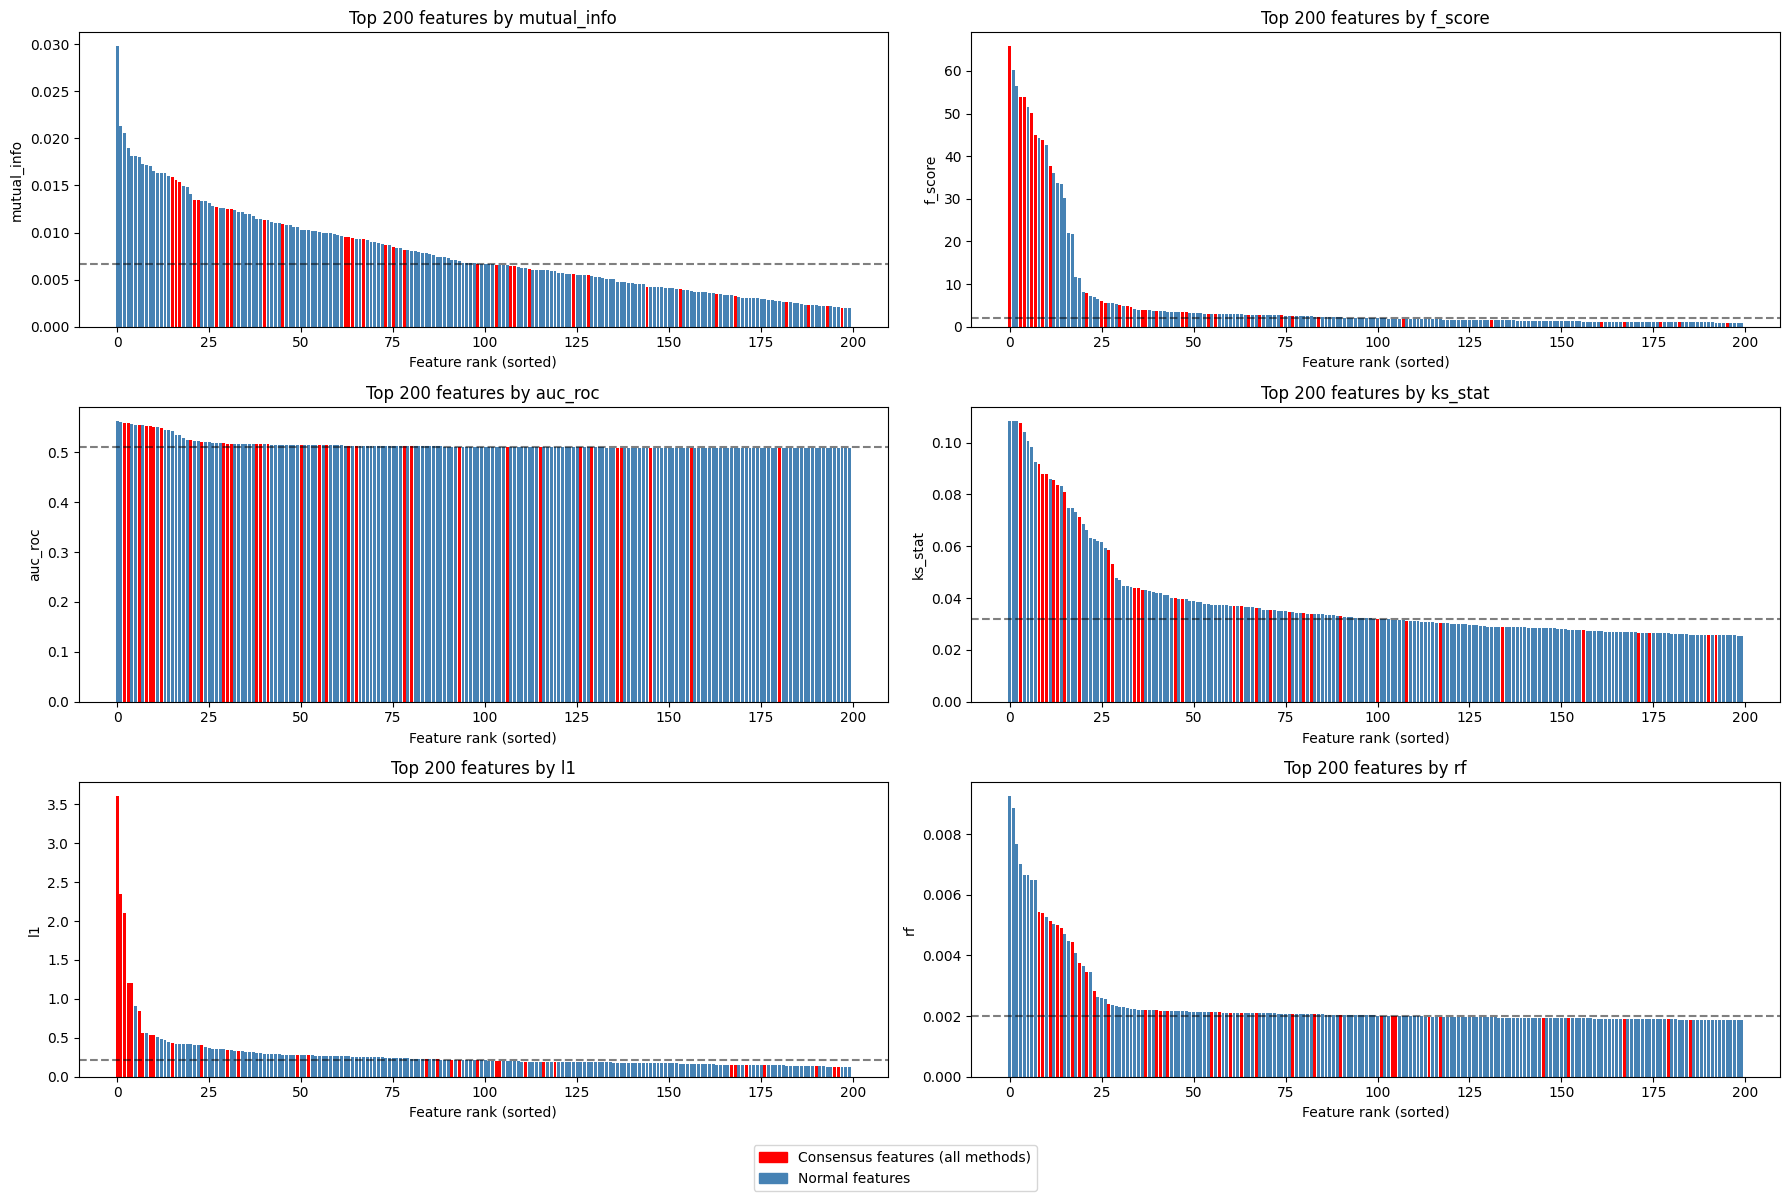

In [150]:
TOP_N = 200

metrics = metric_columns
consensus_mask = results["votes_top_k"] == len(metrics)

n_cols = 2
n_rows = int(np.ceil(len(metrics) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(metrics):

    df = results.sort_values(by=col, ascending=False).head(TOP_N)
    colors = np.where(df["votes_top_k"] == len(metrics), "red", "steelblue")

    axes[i].bar(range(len(df)), df[col], color=colors)

    axes[i].set_title(f"Top {TOP_N} features by {col}")
    axes[i].set_xlabel("Feature rank (sorted)")
    axes[i].set_ylabel(col)

    axes[i].axhline(df[col].median(), linestyle="--", color="black", alpha=0.5)

red_patch = mpatches.Patch(color='red', label='Consensus features (all methods)')
blue_patch = mpatches.Patch(color='steelblue', label='Normal features')

fig.legend(
    handles=[red_patch, blue_patch],
    loc='lower center'
)

plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

In [ ]:
K_VALUES=np.linspace(10, 500, 50).astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_summary = []
sorted_features = results.sort_values("avg_normalized_rank")["feature"].values


for k in K_VALUES:

    selected_features = sorted_features[:k]
    X_sel = x_train_scaled[selected_features]

    accs, precs, recs, scores, profits = [], [], [], [], []

    for train_idx, val_idx in cv.split(X_sel, y_train):

        X_tr, X_val = X_sel.iloc[train_idx], X_sel.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = LogisticRegression(max_iter=5000, solver="lbfgs")

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        accs.append(accuracy_score(y_val, preds))
        precs.append(precision_score(y_val, preds, zero_division=0))
        recs.append(recall_score(y_val, preds))
        scores.append(scoring_function(y_val, preds, k))
        profits.append(profit_function(y_val, preds))

    results_summary.append({
        "k_features": k,
        "accuracy": np.mean(accs),
        "precision": np.mean(precs),
        "recall": np.mean(recs),
        "score": np.mean(scores),
        "profit": np.mean(profits)
    })

cv_results = pd.DataFrame(results_summary)
cv_results.head()

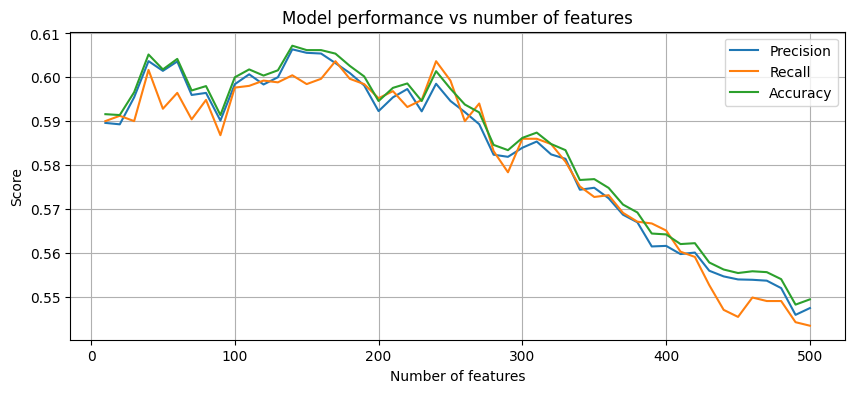

In [170]:
plt.figure(figsize=(10, 4))

plt.plot(cv_results["k_features"], cv_results["precision"], label="Precision")
plt.plot(cv_results["k_features"], cv_results["recall"], label="Recall")
plt.plot(cv_results["k_features"], cv_results["accuracy"], label="Accuracy")

plt.xlabel("Number of features")
plt.ylabel("Score")
plt.title("Model performance vs number of features")
plt.legend()
plt.grid()
plt.show()